In [59]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view # for convolutions
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display

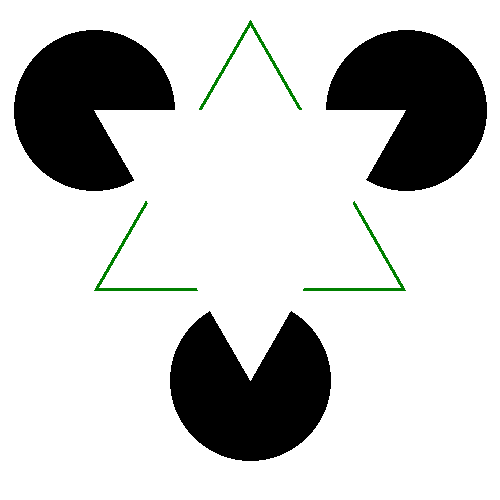

In [60]:
# drawing Kanizsa triangle

# some utilities
def rot2d(angle):
  return np.array([[np.cos(angle), -np.sin(angle)],
                   [np.sin(angle), np.cos(angle)]])
size = 500
center = np.array((size/2, size/2 * 4/5)) # some correction so the triangle fits
unit_x = np.array([1,0])

# actual drawing
img = Image.new("RGB", (size, size), "white")
draw = ImageDraw.Draw(img)

ref_circ_radius = 180
circ_radius = 80

omega_0 = np.pi/2
angles = [omega_0, omega_0 - 2/3 * np.pi, omega_0 - 4/3 * np.pi]
c0 = np.round((rot2d(angles[0]) @ unit_x) * ref_circ_radius + center).tolist()
c1 = np.round((rot2d(angles[1]) @ unit_x) * ref_circ_radius + center).tolist()
c2 = np.round((rot2d(angles[2]) @ unit_x) * ref_circ_radius + center).tolist()

draw.circle(c0, radius=circ_radius, fill="black")
draw.circle(c1, radius=circ_radius, fill="black")
draw.circle(c2, radius=circ_radius, fill="black")
draw.regular_polygon(
    bounding_circle=(center.tolist(), ref_circ_radius),
    n_sides=3,
    outline="green",
    width = 3,
    rotation=0
    )
draw.regular_polygon(
    bounding_circle=(center.tolist(), ref_circ_radius),
    n_sides=3,
    fill="white",
    rotation=180
    )

img.save("kanizsa.png")
img

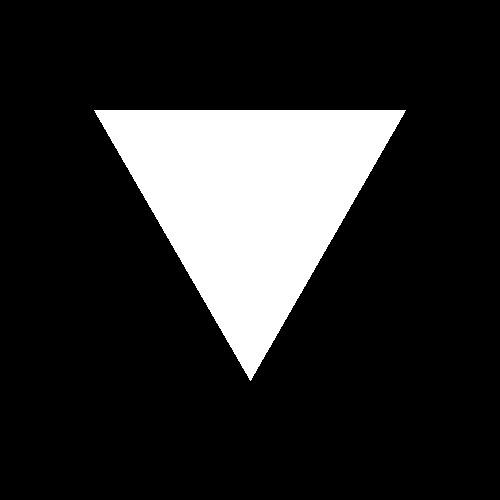

In [61]:
# drawing the mask of inpainting

img = Image.new("RGB", (size, size), "black")
draw = ImageDraw.Draw(img)

draw.regular_polygon(
    bounding_circle=(center.tolist(), ref_circ_radius),
    n_sides=3,
    fill="white",
    rotation=180
    )

img.save("kanizsa_mask.png")
img

bool (500, 500)


/tmp/ipython-input-3654452997.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))


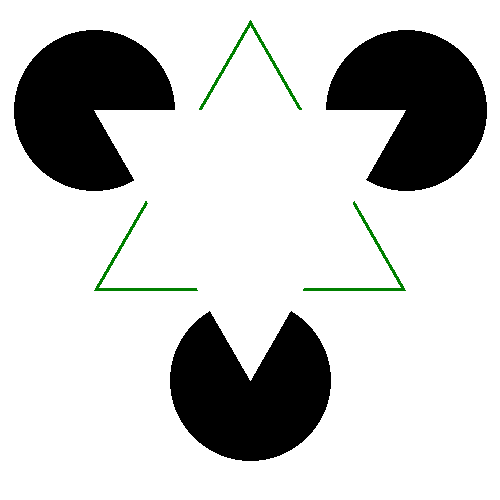

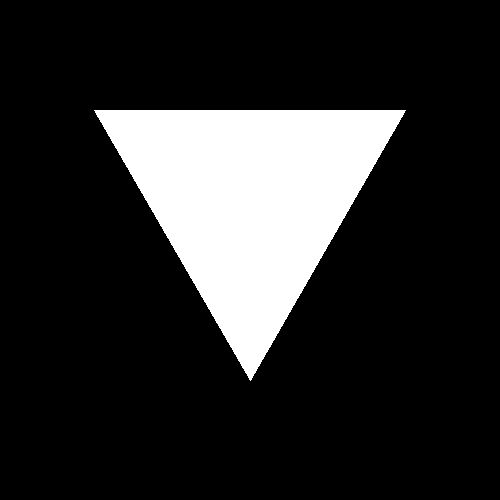

In [88]:
def read_image(path, *, mask=False, grayscale=False, LAB=False):
  "Open and parse image file as a numpy array to process"
  img = Image.open(path)
  if grayscale:
    img = img.convert("L")
    arr = np.array(img)
    return arr/arr.max()
  if mask:
    img = img.convert("1") # masks are just boolean arrays
    return np.array(img)
  if LAB:
    img = img.convert("LAB")
    return np.array(img)

  return np.array(img.convert("RGB"))

def display_img(array, LAB=False):
  if np.issubdtype(array.dtype,float) and len(array.shape) == 2:
    display(Image.fromarray(255 * array / array.max()).convert("L"))
  elif np.issubdtype(array.dtype,bool) and len(array.shape) == 2:
    display(Image.fromarray(array))
  else:
    display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))

img = read_image("kanizsa.png")
img_gray = read_image("kanizsa.png", grayscale=True)
img_lab = read_image("kanizsa.png", LAB=True)
mask = read_image("kanizsa_mask.png", mask = True)
print(mask.dtype, mask.shape)

display_img(img)
display_img(mask)

In [63]:
target_mask = mask # Omega
target_mask_num = target_mask.astype(np.int8)
source_mask = ~ mask # Phi = I - Omega

In [64]:
def pad_image(img, pad_size):
  """creates a padded image by repeating the margins"""
  # the corner will just be the corner pixel as a square
  def gen_corner_pad(value):
    return np.full(
        shape=(pad_size, pad_size, *img.shape[2:]),
        fill_value = value,
        dtype = img.dtype,
    )

  #pad above

  # this line needs some shape casting to keep the array bidimensional
  # that is shape == (1, width) rathern than shape == (width, )
  upper_row = img[0,:].reshape((1,*img.shape[1:]))

  above_pad = np.repeat(upper_row, pad_size, axis=0)
  new_img = np.vstack([above_pad, img])

  # pad left

  corner_pad = gen_corner_pad(img[0,0])

  left_column = img[:,0].reshape((img.shape[0], 1, *img.shape[2:]))
  left_pad = np.repeat(left_column, pad_size, axis=1)

  left_pad = np.vstack([corner_pad, left_pad])

  new_img = np.hstack([left_pad, new_img])

  # pad right

  corner_pad = gen_corner_pad(img[0,-1])
  right_column = img[:,-1].reshape((img.shape[0], 1, *img.shape[2:]))
  right_pad = np.repeat(right_column, pad_size, axis=1)
  right_pad = np.vstack([corner_pad, right_pad])

  new_img = np.hstack([new_img, right_pad])

  # pad bottom

  bottom_row = img[-1,:].reshape((1, *img.shape[1:]))
  bottom_pad = np.repeat(bottom_row, pad_size, axis=0)

  bottom_pad = np.hstack([gen_corner_pad(img[-1,0]),
                          bottom_pad,
                          gen_corner_pad(img[-1,-1])])

  new_img = np.vstack([new_img, bottom_pad])

  return new_img


def convolve(img, ker):
  m = ker.shape[0]
  assert ker.shape[1] == m and len(ker.shape) == 2, "kernel must be square"

  pad_size = int(m//2)
  padded_img = pad_image(img, pad_size)
  windows = sliding_window_view(padded_img, (*ker.shape,*img.shape[2:]))
  convolved = (windows * ker[np.newaxis, np.newaxis, :]).sum(axis=(2,3))
  return convolved

In [65]:
# sobel gradient
def sobel_grad(img):
  sobel_x = np.array([[-1, 0, +1],
                      [-2, 0, +2],
                      [-1, 0, +1]])
  sobel_y = sobel_x.T

  dx = convolve(img, sobel_x)
  dy = convolve(img, sobel_y)
  grad = np.stack([dx,dy], axis=2)
  return grad

In [66]:
def naive_grad(img):
  kerx =np.array([[ 0, 0, 0],
                  [-1, 0, 1],
                  [ 0, 0, 0]])

  kery =np.array([[ 0, 1, 0],
                  [ 0, 0, 0],
                  [ 0,-1, 0]])

  return np.stack( [convolve(img,kerx),  convolve(img,kery)], axis=2 )


In [67]:
def plot_grad(img, grad):
  grad_norm = np.linalg.norm(grad, axis=2)
  grad_unit = np.divide(grad,grad_norm[:,:,np.newaxis], where= grad_norm[:,:,np.newaxis] > 0)


  dx, dy = grad_unit[:,:,0], grad_unit[:,:,1]
  indices = np.nonzero(grad_norm)
  chosen_indices = np.random.uniform(size=len(indices[0])) < 0.5 # too many values, lets just sample
  indices = (indices[0][chosen_indices], indices[1][chosen_indices])


  fig, ax = plt.subplots()
  ax.set_xlim(0,target_mask_num.shape[0])
  ax.set_ylim(0,target_mask_num.shape[1])
  ax.invert_yaxis()
  if len(img.shape) == 3:
    # parse as LAB
    img = Image.fromarray(img, mode="LAB").convert("RGB")

  ax.imshow(img)
  ax.quiver(indices[1],indices[0],dx[indices], dy[indices], color="red", scale=10)


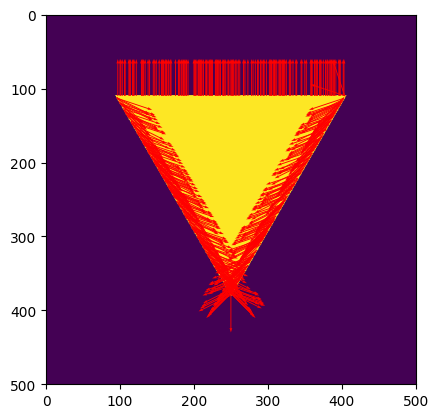

In [68]:
grad = sobel_grad(target_mask_num)
grad = target_mask[:,:, np.newaxis] * grad # keep only gradients inside the mask

plot_grad(target_mask, grad)

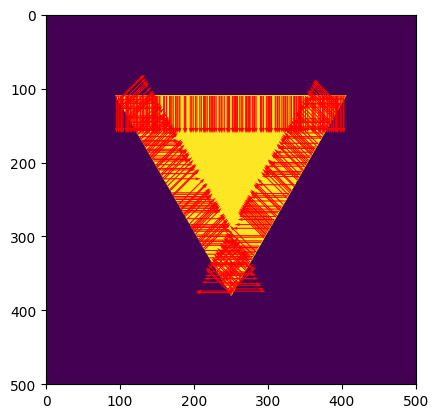

In [69]:

grad = naive_grad(target_mask_num)
grad = target_mask[:,:, np.newaxis] * grad # keep only gradients inside the mask


plot_grad(target_mask, grad)


/tmp/ipython-input-398841741.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode="LAB").convert("RGB")


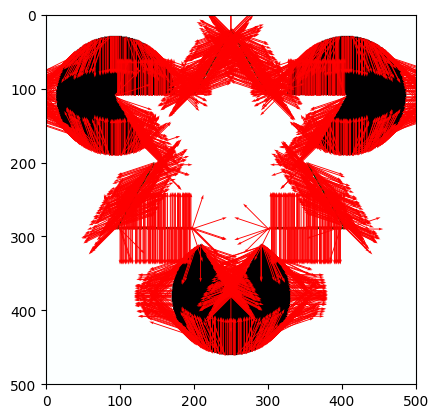

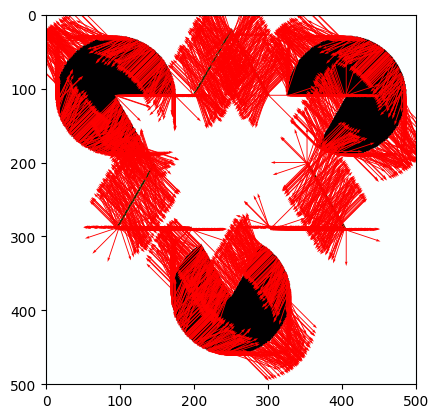

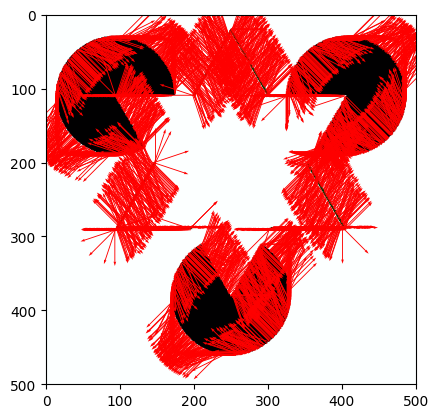

In [94]:
grad = sobel_grad(img_gray)

plot_grad(img, grad)
plot_grad(img, grad @ rot2d(np.pi/2))
plot_grad(img, grad @ rot2d(-np.pi/2))

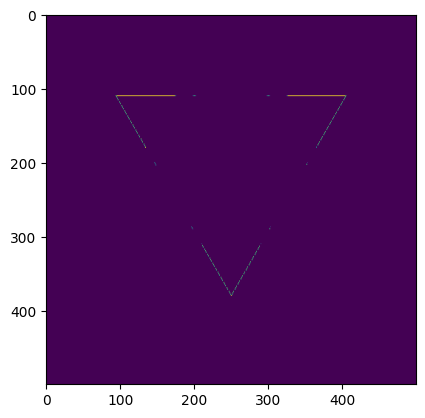

In [111]:
contour_normals =  target_mask[:,:, np.newaxis] * naive_grad(target_mask_num)
contour_normals = contour_normals.reshape((*contour_normals.shape,1))
isophotes = sobel_grad(img_gray)
isophotes_t = isophotes.reshape((*isophotes.shape[:2],1,2))

data_values = abs(isophotes_t @ contour_normals).reshape(img_gray.shape)
confidence = target_mask.astype(int)

plt.imshow(data_values)